In [ ]:
import numpy as np
import pandas as pd

from match3.game.level import Level, Objective, ObjectiveType
from match3.players.random_player import RandomPlayer
from match3.simulation.simulator import simulate_games

import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
GOAL_RANGE = np.arange(3,50)
MOVE_BUDGET = 20
NUM_GAMES = 100

In [8]:
rng = np.random.default_rng(42)
player = RandomPlayer(rng)

In [9]:
results_dict = {}
for goal in GOAL_RANGE:
    level = Level(
        name=f"Collect {goal} Red Candies",
        moves=MOVE_BUDGET,
        objective=Objective(
                type=ObjectiveType.COLLECT,
                target=int(goal),
                candy_type=0,
            )
    )
    results = simulate_games(level, player, n_games=NUM_GAMES, rng=rng)
    results_df = pd.DataFrame(results)

    win_rate = results_df["won"].mean()
    results_dict[goal] = win_rate

In [11]:
win_df = pd.DataFrame.from_dict(results_dict, orient="index", columns=["win_rate"])

Text(0, 0.5, 'Win Rate')

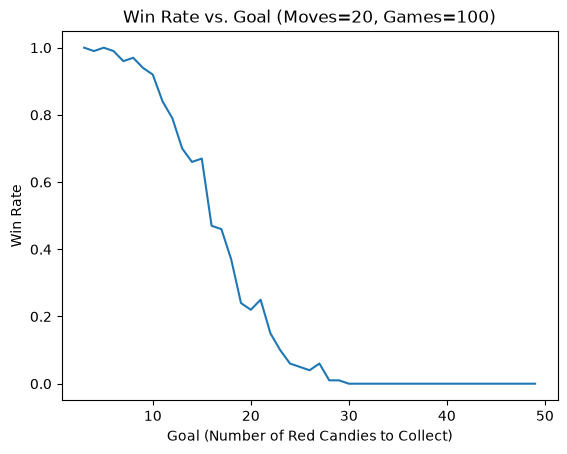

In [12]:
plt.plot(list(results_dict.keys()), list(results_dict.values()))
plt.title(f"Win Rate vs. Goal (Moves={MOVE_BUDGET}, Games={NUM_GAMES})")
plt.xlabel("Goal (Number of Red Candies to Collect)")
plt.ylabel("Win Rate")

In [13]:
import cProfile
import pstats

cProfile.run(
    """
results = simulate_games(
    level=level,
    player=player,
    n_games=100,
    rng=np.random.default_rng(42),
)
""",
    "simulation_profile.prof",
)

stats = pstats.Stats("simulation_profile.prof")
stats.sort_stats("cumtime").print_stats(20)

Sat Sep 19 19:25:09 2026    simulation_profile.prof

         4492771 function calls (4492769 primitive calls) in 4.959 seconds

   Ordered by: cumulative time
   List reduced from 69 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    5.005    5.005 {built-in method builtins.exec}
        1    0.000    0.000    5.005    5.005 <string>:1(<module>)
        1    0.000    0.000    5.005    5.005 /Users/jonathanpillerJon/code/match-3-simulation/src/match3/simulation/simulator.py:49(simulate_games)
      100    0.002    0.000    5.005    0.050 /Users/jonathanpillerJon/code/match-3-simulation/src/match3/simulation/simulator.py:22(simulate_game)
     1991    0.088    0.000    4.731    0.002 /Users/jonathanpillerJon/code/match-3-simulation/src/match3/players/random_player.py:14(choose_move)
   224982    0.039    0.000    4.638    0.000 /Users/jonathanpillerJon/code/match-3-simulation/src/match3/game/game.py:30(ch